M ARISH SC25M159

MA642 Advanced Machine Learning Lab

Assignment-II

**5. Apply ICA on MEG data
http://research.ics.aalto.fi/ica/eegmeg/MEG data.html.
Explain the experimental results obtained.**

In [5]:
import numpy as np
import pandas as pd
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the CSV file, specifying space as a separator and no header
meg = pd.read_csv("MEG_art", sep=r'\s+', header=None)

# Display first few rows to check
print("MEG Dataset -", (meg.shape)) # prints number of rows and columns
print(type(meg))
print(meg.head())

MEG Dataset - (122, 17730)
<class 'pandas.core.frame.DataFrame'>
      0         1         2         3         4         5         6      \
0  -48.1010    8.9292  -15.4601 -101.8247 -134.0560  -65.4968   32.9820   
1  -49.9636 -142.8894 -226.2582 -211.3216 -137.6300  -99.0562  -95.9607   
2   33.2980   -4.8167  -56.2879   -4.5970   89.8988   85.8677   32.8257   
3  -71.7910  -66.8023  -74.1104  -59.1573   28.9549   83.8565  -22.1502   
4  159.5690   61.2882    4.1433   52.4750  139.9503  193.6496  202.4394   

      7         8         9      ...     17720     17721     17722     17723  \
0   63.1649   -4.5310  -93.0902  ...   -7.9927    7.8765  -10.8757  -79.0469   
1 -103.6243 -137.4798 -162.0336  ...  -34.8002  -54.7425  -79.1679  -83.1431   
2   49.0272   69.6223    8.4081  ... -152.9107 -110.5973 -112.1067 -137.3355   
3 -199.5665 -256.4766 -176.8518  ...  119.5210  123.6075  151.4310  121.6914   
4  161.1277   80.2623   29.0592  ...  -12.4385   10.9972   52.5224   47.1760   

   

ICA - Independent Component Analysis

In [10]:
X_features = meg.to_numpy()
X = X_features.T # (3,2000)

print("Original Data Shape:", X.shape)

# Preprocessing (Center + Scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Original Data Shape: (17730, 122)


In [7]:
# Apply ICA
n_components = 122   # reduced for faster convergence
ica = FastICA(
    n_components=n_components,
    algorithm='parallel',   # parallel or deflation
    whiten='unit-variance',
    max_iter=300,
    tol=1e-4,
    random_state=42
)

S = ica.fit_transform(X_scaled)   # Source signals
A = ica.mixing_                   # Mixing matrix

In [11]:
print("\nRecovered source signals :", S.shape)
print(S)


Recovered source signals : (17730, 122)
[[ 0.51676524  1.54298828 -0.68979225 ...  1.46796544 -0.33958607
   0.38818672]
 [-0.09099952  1.4593415  -1.21742476 ...  1.27264134 -0.74218993
  -0.45459511]
 [-0.03646742  1.39064708 -0.8923323  ...  0.82003571 -0.90515141
   0.09071704]
 ...
 [-0.18532372 -0.48108289  0.44809784 ... -0.85542122 -0.51693177
   0.41171619]
 [ 0.16518573  0.02986875  0.06220754 ... -0.2843113  -0.49965691
   1.0870096 ]
 [ 0.1654485  -0.04575155 -0.61249401 ... -0.06894041 -0.50809341
   1.01847021]]


In [8]:
# Report Parameters
print("\nICA PARAMETERS")
print("Number of Components:", ica.n_components)
print("Algorithm:", ica.algorithm)
print("Whitening:", ica.whiten)
print("Max Iterations:", ica.max_iter)
print("Tolerance:", ica.tol)
print("Random State:", ica.random_state)

print("\nOUTPUT SHAPES")
print("Source Signals Shape:", S.shape)
print("Mixing Matrix Shape:", A.shape)


ICA PARAMETERS
Number of Components: 122
Algorithm: parallel
Whitening: unit-variance
Max Iterations: 300
Tolerance: 0.0001
Random State: 42

OUTPUT SHAPES
Source Signals Shape: (17730, 122)
Mixing Matrix Shape: (122, 122)


Explanation of Experimental Results

1. Mixed MEG Signals

The recorded MEG signals are mixtures of:
* Brain neural activity
* Eye movement artifacts
* Muscle noise
* External electromagnetic interference

These signals are highly correlated and overlapping.

2. After Applying ICA

FastICA separates signals into statistically independent components:
* Some components represent actual neural brain activity
* Some correspond to noise/artifacts (eye blinks etc.)
* Each component becomes more interpretable and less correlated

3. Observations

* Independent components show distinct temporal patterns
* Artifact signals appear as strong spikes in certain components
* Brain-related sources appear smoother and structured

4. Conclusion

Applying ICA on MEG data successfully performs:

* Blind Source Separation
* Noise and artifact isolation
* Improved analysis of neural activity

Hence, ICA is effective for MEG signal decomposition and preprocessing in brain signal analysis.

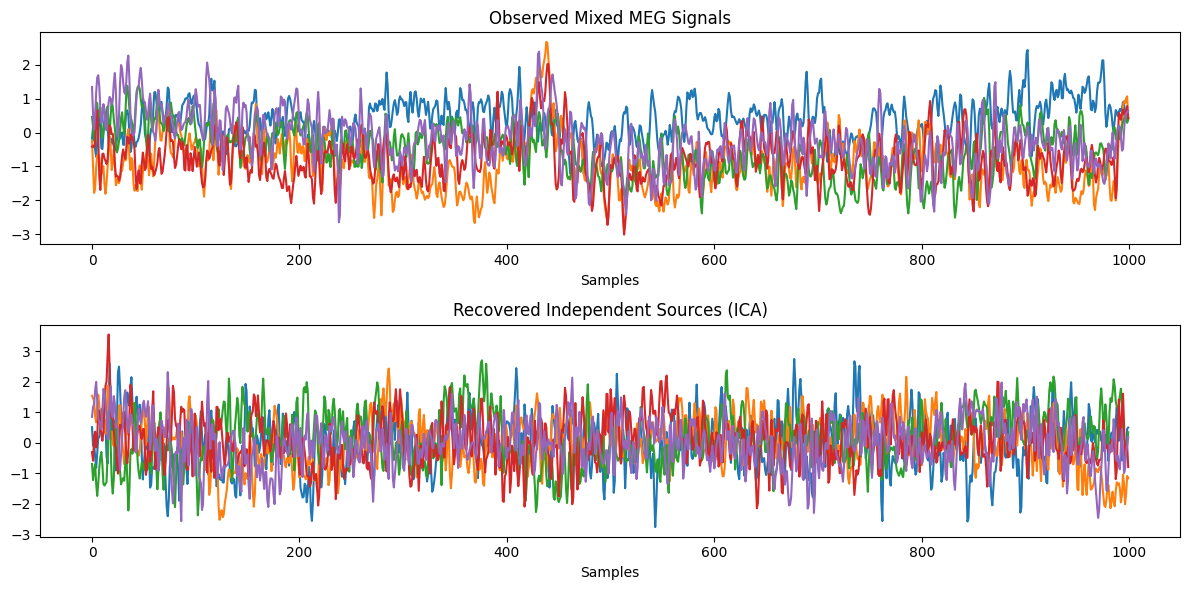

In [9]:
# Plot Observed vs Sources
plt.figure(figsize=(12,6))

# Observed signals
plt.subplot(2,1,1)
plt.title("Observed Mixed MEG Signals")
for i in range(5):
    plt.plot(X_scaled[:1000, i])
plt.xlabel("Samples")

# Independent components
plt.subplot(2,1,2)
plt.title("Recovered Independent Sources (ICA)")
for i in range(5):
    plt.plot(S[:1000, i])
plt.xlabel("Samples")

plt.tight_layout()
plt.show()

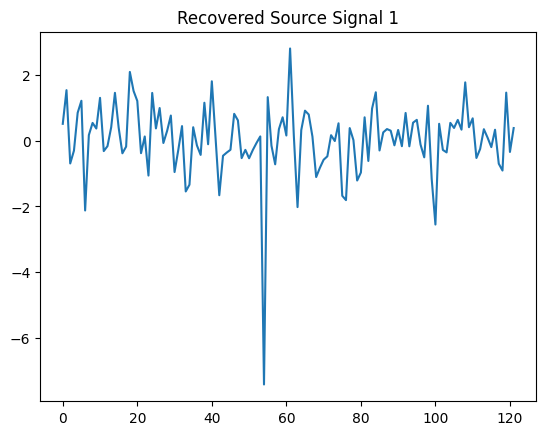

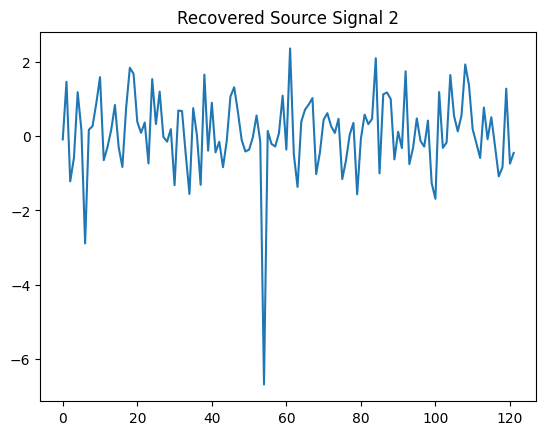

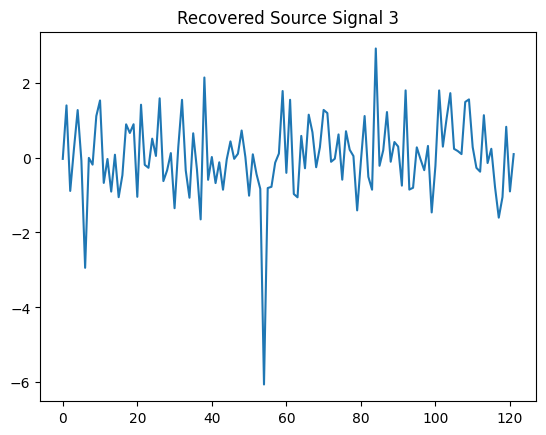

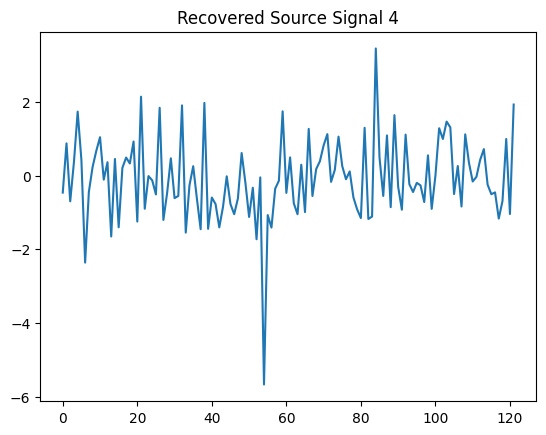

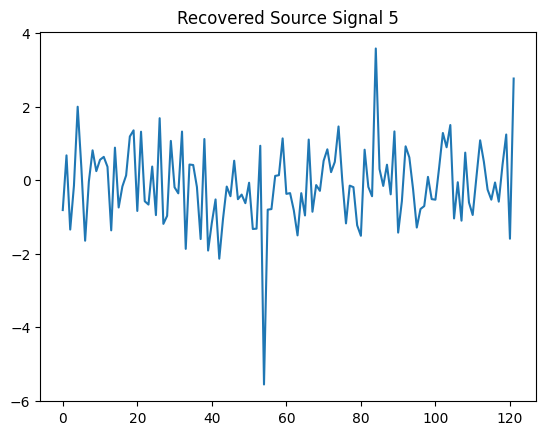

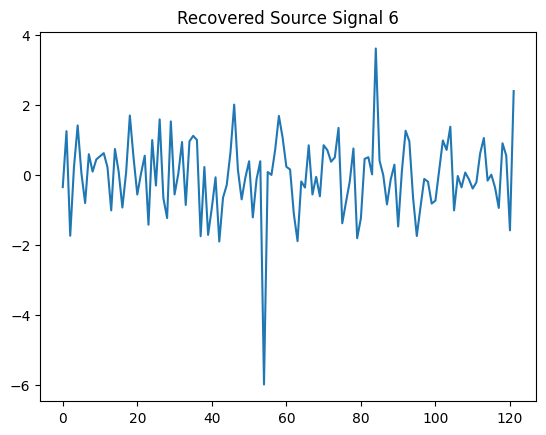

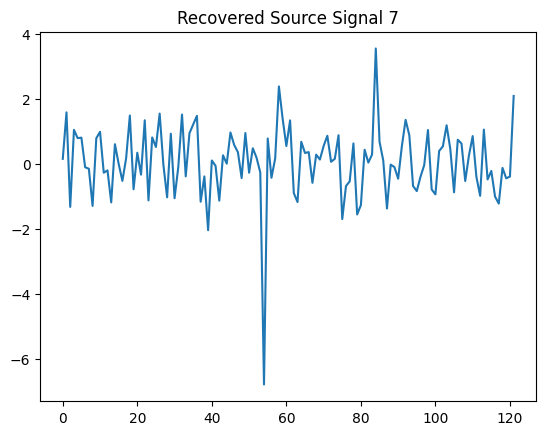

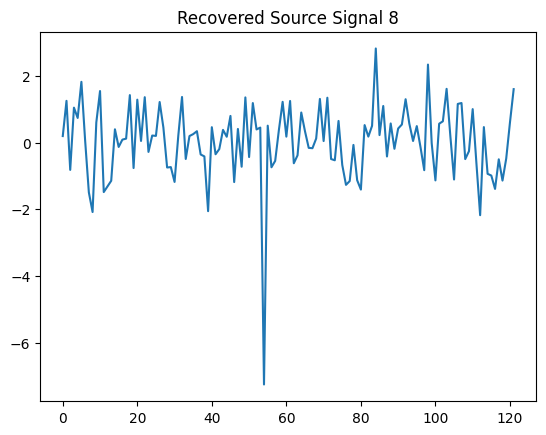

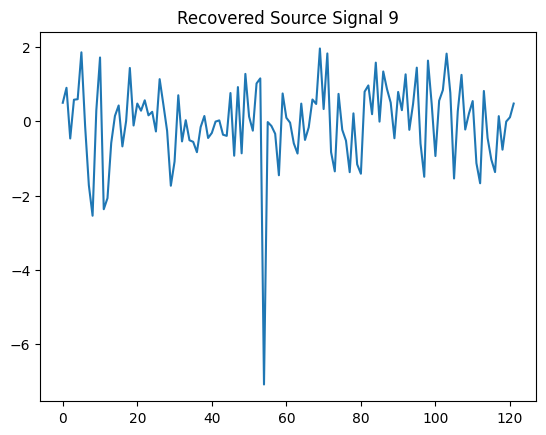

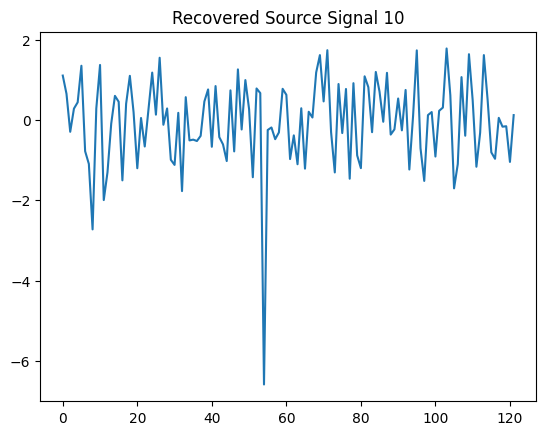

In [13]:
import matplotlib.pyplot as plt

for i in range(10):
    plt.plot(S[i])
    plt.title(f"Recovered Source Signal {i+1}")
    plt.show()